In [1]:
# PTB-XL xLSTM Model
import os
import ast
import wfdb
import torch
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

from pathlib import Path
from tqdm import tqdm
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc

In [2]:
# Paths
dataset_path = Path("/users/PLS0150/shreeshtee/PTBXL-Dataset-Thesiswork/physionet.org/files/ptb-xl/1.0.3")
ptbxl_path = dataset_path / "ptbxl_database.csv"

In [3]:
# Load Metadata
df = pd.read_csv(ptbxl_path)
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)
df["scp_keys"] = df["scp_codes"].apply(lambda x: list(x.keys()))

target_labels = ["NORM","AFIB","PVC","LVH","IMI","ASMI","LAFB","IRBBB"]
df["scp_filtered"] = df["scp_keys"].apply(lambda x: [k for k in x if k in target_labels])
df = df[df["scp_filtered"].map(len) > 0].reset_index(drop=True)

mlb = MultiLabelBinarizer(classes=target_labels)
y = mlb.fit_transform(df["scp_filtered"])

# Patient-wise Split
patients = df["patient_id"].unique()
train_patients, test_patients = train_test_split(
    patients, test_size=0.2, random_state=42
)

train_mask = df["patient_id"].isin(train_patients)
test_mask  = df["patient_id"].isin(test_patients)

X_train = df[train_mask].reset_index(drop=True)
X_test  = df[test_mask].reset_index(drop=True)

y_train = y[train_mask]
y_test  = y[test_mask]

print("Train:", len(X_train), "Test:", len(X_test))

# ECG Loader (Per-lead Z-score)
def load_ecg(path):
    record = wfdb.rdrecord(path)
    signal = record.p_signal.T  # (12, 1000)

    mean = signal.mean(axis=1, keepdims=True)
    std  = signal.std(axis=1, keepdims=True) + 1e-8
    signal = (signal - mean) / std

    return signal  # (12, 1000)

class PTBXL_Dataset(Dataset):
    def __init__(self, df, labels, base_dir):
        self.df = df
        self.labels = labels
        self.base_dir = base_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.base_dir, row["filename_lr"])
        signal = load_ecg(path)  # (12, 1000)

        return (
            torch.tensor(signal, dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

train_dataset = PTBXL_Dataset(X_train, y_train, dataset_path)
test_dataset  = PTBXL_Dataset(X_test,  y_test,  dataset_path)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

signals, _ = next(iter(train_loader))
print("Signal shape:", signals.shape)  # MUST be (B, 12, 1000)

Train: 14303 Test: 3573
Signal shape: torch.Size([32, 12, 1000])


In [4]:
# xLSTM Model
class xLSTMECG(nn.Module):
    def __init__(self, input_channels=12, num_classes=10, hidden_size=128, num_layers=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_channels, 32, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)

        self.lstm = nn.LSTM(input_size=64, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = x.permute(0, 2, 1)  # [B, T, C]
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # last time step
        return self.fc(x)

In [5]:
# Training loop with Weights & Biases logging
import wandb

wandb.init(
    project="Hybrid-CNN-Transformer-ECG-notebooks_individual_notebooks",
    name="xLSTM"
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: sdhakal13 (sdhakal13-youngstown-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [7]:
# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = xLSTMECG(input_channels=12, num_classes=len(target_labels)).to(device)

# Class weights
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
class_weights = torch.tensor(neg_counts / (pos_counts + 1e-8),dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(),lr=2e-4,weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

epochs = 100
best_auc = 0

for epoch in range(epochs):

    # ============ TRAINING ============
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for signals, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        signals = signals.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

        # Track accuracy during training
        with torch.no_grad():
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels.bool()).sum().item()
            total += labels.numel()

    scheduler.step()

    avg_loss = train_loss / len(train_loader)
    avg_acc = correct / total

    # ============ VALIDATION ============
    model.eval()
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for signals, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            signals = signals.to(device)
            outputs = model(signals)
            preds_list.append(torch.sigmoid(outputs).cpu().numpy())
            labels_list.append(labels.numpy())

    preds = np.vstack(preds_list)
    targets = np.vstack(labels_list)

    val_auc = roc_auc_score(targets, preds, average="macro")

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"  Train Loss:  {avg_loss:.4f}")
    print(f"  Train Acc:   {avg_acc:.4f}")
    print(f"  Val AUC:     {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), "best_hybrid_model.pth")
        print(f"  Best model saved! (AUC: {val_auc:.4f})")

    # W&B logging 
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "train_accuracy": avg_acc,
        "val_auc": val_auc
    })

print(f"Best Macro AUC: {best_auc:.4f}")

Epoch 1/100 [Val]: 100%|██████████| 112/112 [00:46<00:00,  2.40it/s]



Epoch 1/100
  Train Loss:  1.0990
  Train Acc:   0.6017
  Val AUC:     0.7125
  Best model saved! (AUC: 0.7125)


Epoch 2/100 [Val]: 100%|██████████| 112/112 [00:05<00:00, 20.36it/s]



Epoch 2/100
  Train Loss:  1.0025
  Train Acc:   0.6663
  Val AUC:     0.7582
  Best model saved! (AUC: 0.7582)


Epoch 3/100 [Val]: 100%|██████████| 112/112 [00:05<00:00, 20.24it/s]


...


Epoch 98/100
  Train Loss:  0.2236
  Train Acc:   0.9452
  Val AUC:     0.9570


Epoch 99/100 [Val]: 100%|██████████| 112/112 [00:05<00:00, 20.23it/s]



Epoch 99/100
  Train Loss:  0.2215
  Train Acc:   0.9462
  Val AUC:     0.9572


Epoch 100/100 [Val]: 100%|██████████| 112/112 [00:05<00:00, 20.65it/s]


Epoch 100/100
  Train Loss:  0.2188
  Train Acc:   0.9462
  Val AUC:     0.9571
Best Macro AUC: 0.9579


In [8]:
# Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for signals, labels in test_loader:
        signals, labels = signals.to(device), labels.to(device)
        outputs = model(signals)
        y_true.append(labels.cpu().numpy())
        y_pred.append(torch.sigmoid(outputs).cpu().numpy())

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print("Classification Report:")
print(classification_report(y_true > 0.5, y_pred > 0.5, target_names=mlb.classes_))
print("Macro ROC-AUC:", roc_auc_score(y_true, y_pred, average='macro'))

Classification Report:
              precision    recall  f1-score   support

        NORM       0.90      0.90      0.90      1919
        AFIB       0.81      0.87      0.84       286
         PVC       0.81      0.90      0.85       238
         LVH       0.46      0.78      0.58       442
         IMI       0.59      0.84      0.69       521
        ASMI       0.64      0.87      0.74       458
        LAFB       0.68      0.88      0.77       313
       IRBBB       0.48      0.76      0.59       232

   micro avg       0.71      0.87      0.78      4409
   macro avg       0.67      0.85      0.74      4409
weighted avg       0.74      0.87      0.79      4409
 samples avg       0.77      0.88      0.80      4409

Macro ROC-AUC: 0.9571201571034483


/users/PLS0150/shreeshtee/.conda/envs/acorn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
 # Helper function to compute macro-average ROC
def compute_macro_roc(y_true, y_pred):
    from sklearn.metrics import roc_curve, auc
    import numpy as np

    n_classes = y_true.shape[1]
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}

    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    return all_fpr, mean_tpr, macro_auc

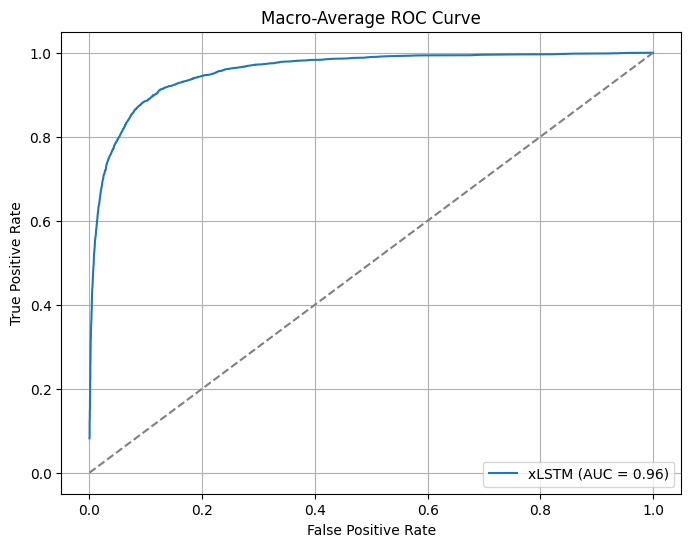

In [10]:
# Plot macro-average ROC
fpr, tpr, macro_auc = compute_macro_roc(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'xLSTM (AUC = {macro_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Macro-Average ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

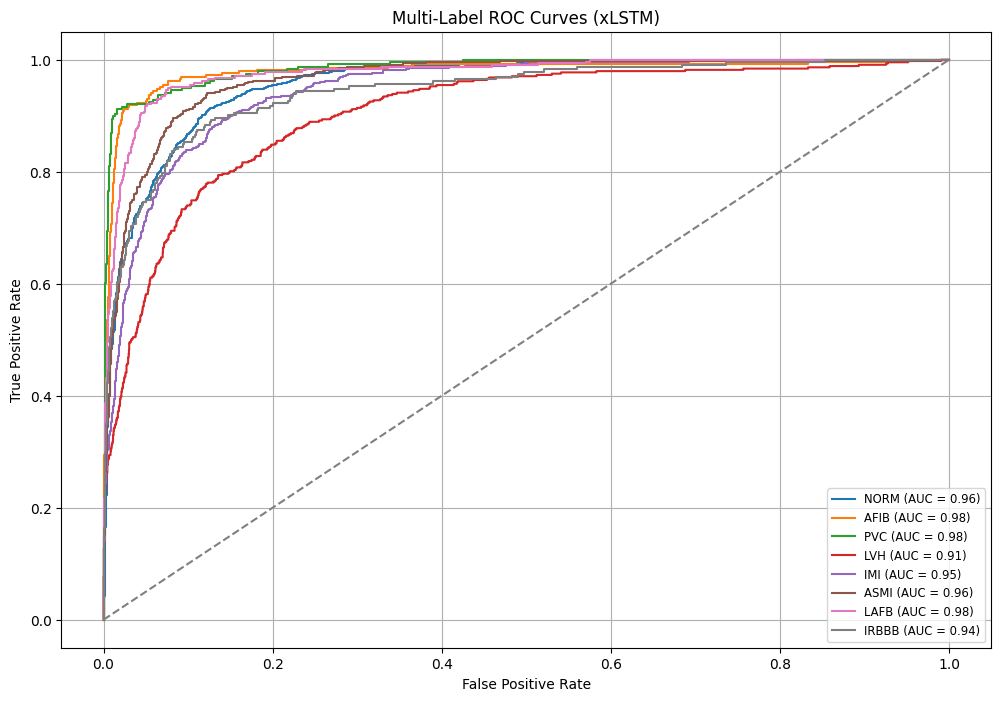

In [11]:
# ROC Curves
plt.figure(figsize=(12, 8))
for i, label in enumerate(mlb.classes_):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Label ROC Curves (xLSTM)')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)
plt.show()

In [12]:
import numpy as np

# After evaluation
np.save("y_true_xlstm.npy", y_true)
np.save("y_pred_xlstm.npy", y_pred)
